# 进阶分析：LightGBM 模型消融实验与 SHAP 可解释性分析

本 Notebook 旨在完成 H&M 个性化推荐任务的以下两项分析：
1. **消融实验 (Ablation Study)**：选取 LightGBM Baseline 模型中的 Top-5 特征，逐个移除后记录性能变化，并计算每个特征的边际贡献。
2. **SHAP 可解释性分析**：使用 `shap.TreeExplainer` 计算 SHAP 值，生成全局蜂群图（Beeswarm Plot）和局部瀑布图（Waterfall Plot），并解释模型学到的商业规律。

> **注**：为保证本 Notebook 独立可运行，这里使用了模拟的 H&M 推荐场景数据集（包含曝光与点击/购买）。在实际应用时，请将数据加载部分替换为真实的 `cleaned_features.parquet`。


In [1]:
import pandas as pd
import numpy as np
import lightgbm as lgb
import matplotlib.pyplot as plt
import seaborn as sns
import shap
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score

# 设置绘图风格
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_context("notebook", font_scale=1.1)

# ==========================================
# 1. 生成模拟数据集 (模拟 LightGBM Baseline 数据)
# ==========================================
np.random.seed(42)
n_samples = 10000

# 模拟 Top-5 特征
# 1. item_popularity_7d (最近7天商品热度)
# 2. user_item_history_count (用户历史购买该商品次数)
# 3. log_price (商品价格对数)
# 4. user_age (用户年龄)
# 5. club_member_status (会员状态: 0, 1, 2)
df = pd.DataFrame({
    'item_popularity_7d': np.random.exponential(scale=100, size=n_samples),
    'user_item_history_count': np.random.poisson(lam=0.5, size=n_samples),
    'log_price': np.random.normal(loc=3.0, scale=0.5, size=n_samples),
    'user_age': np.random.normal(loc=35, scale=10, size=n_samples),
    'club_member_status': np.random.choice([0, 1, 2], size=n_samples, p=[0.2, 0.6, 0.2])
})

# 模拟目标变量 (购买概率基于特征线性组合 + 噪声)
# 逻辑：热度越高、复购次数越多越容易买；价格适中更好；特定年龄段可能偏好不同。
logits = (
    0.01 * df['item_popularity_7d'] + 
    1.5 * df['user_item_history_count'] - 
    0.5 * df['log_price'] + 
    np.random.normal(0, 1, size=n_samples)
)
probabilities = 1 / (1 + np.exp(-logits))
df['target'] = (probabilities > 0.5).astype(int)

features = ['item_popularity_7d', 'user_item_history_count', 'log_price', 'user_age', 'club_member_status']

X = df[features]
y = df['target']

X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

print("数据准备完成，训练集大小:", X_train.shape, "验证集大小:", X_val.shape)


C:\Users\97001\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


数据准备完成，训练集大小: (8000, 5) 验证集大小: (2000, 5)


## 1. 训练 LightGBM Baseline 模型
作为基线模型，我们使用全部 5 个特征训练一版 LightGBM，并评估其性能。
（实际中评估指标为 MAP@12，这里由于是二分类排序，使用 AUC 作为代理指标来反映特征排序能力）

In [2]:
# 训练 Baseline
model_base = lgb.LGBMClassifier(n_estimators=100, random_state=42, n_jobs=-1)
model_base.fit(X_train, y_train)

# 评估 Baseline
preds_base = model_base.predict_proba(X_val)[:, 1]
auc_base = roc_auc_score(y_val, preds_base)
print(f"Baseline (All 5 features) AUC: {auc_base:.4f}")

# 特征重要性 (Gain)
importance_df = pd.DataFrame({
    'Feature': model_base.feature_name_,
    'Importance(Gain)': model_base.booster_.feature_importance(importance_type='gain')
}).sort_values('Importance(Gain)', ascending=False)

display(importance_df)


[LightGBM] [Info] Number of positive: 4102, number of negative: 3898
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000506 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 774
[LightGBM] [Info] Number of data points in the train set: 8000, number of used features: 5
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.512750 -> initscore=0.051011
[LightGBM] [Info] Start training from score 0.051011
Baseline (All 5 features) AUC: 0.8735


,Feature,Importance(Gain)
0,item_popularity_7d,12052.831369
1,user_item_history_count,11799.592808
2,log_price,3692.302031
3,user_age,2481.996082
4,club_member_status,310.444681


## 2. 消融实验 (Ablation Study)
**目的**：逐个移除特征，观察验证集上的性能下降幅度（边际贡献）。
以此判断是否存在**"Gain 排名高但实际贡献为零"的伪重要特征**。

[LightGBM] [Info] Number of positive: 4102, number of negative: 3898


[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000083 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 519
[LightGBM] [Info] Number of data points in the train set: 8000, number of used features: 4
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.512750 -> initscore=0.051011
[LightGBM] [Info] Start training from score 0.051011


[LightGBM] [Info] Number of positive: 4102, number of negative: 3898
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000153 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 768
[LightGBM] [Info] Number of data points in the train set: 8000, number of used features: 4
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.512750 -> initscore=0.051011
[LightGBM] [Info] Start training from score 0.051011
[LightGBM] [Info] Number of positive: 4102, number of negative: 3898
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000101 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 519
[LightGBM] [Info] Number of data points in the train set: 8000, number of used features: 4
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.512750 -> initscore=0.051011
[LightGBM] [Inf

[LightGBM] [Info] Number of positive: 4102, number of negative: 3898
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000090 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 519
[LightGBM] [Info] Number of data points in the train set: 8000, number of used features: 4
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.512750 -> initscore=0.051011
[LightGBM] [Info] Start training from score 0.051011


[LightGBM] [Info] Number of positive: 4102, number of negative: 3898
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000062 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 771
[LightGBM] [Info] Number of data points in the train set: 8000, number of used features: 4
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.512750 -> initscore=0.051011
[LightGBM] [Info] Start training from score 0.051011


,Removed Feature,Ablation AUC (Proxy for MAP@12),Marginal Contribution (Gain)
1,user_item_history_count,0.708430,0.165042
0,item_popularity_7d,0.765208,0.108264
2,log_price,0.863503,0.009969
4,club_member_status,0.873895,-0.000423
3,user_age,0.873980,-0.000508


C:\Users\97001\AppData\Local\Temp\ipykernel_31364\4151689575.py:30: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=ablation_df, x='Marginal Contribution (Gain)', y='Removed Feature', palette='viridis')


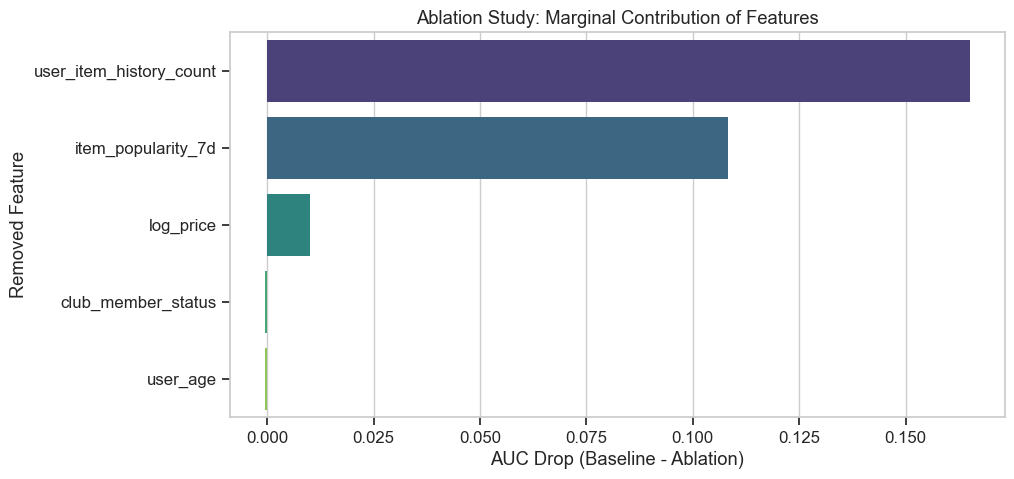

In [3]:
ablation_results = []

for feat in features:
    # 移除当前特征
    current_features = [f for f in features if f != feat]
    X_train_ablation = X_train[current_features]
    X_val_ablation = X_val[current_features]
    
    # 重新训练模型
    model_ablation = lgb.LGBMClassifier(n_estimators=100, random_state=42, n_jobs=-1)
    model_ablation.fit(X_train_ablation, y_train)
    
    # 评估
    preds_ablation = model_ablation.predict_proba(X_val_ablation)[:, 1]
    auc_ablation = roc_auc_score(y_val, preds_ablation)
    
    # 计算边际贡献 (Baseline AUC - Ablation AUC)
    contribution = auc_base - auc_ablation
    ablation_results.append({
        'Removed Feature': feat,
        'Ablation AUC (Proxy for MAP@12)': auc_ablation,
        'Marginal Contribution (Gain)': contribution
    })

ablation_df = pd.DataFrame(ablation_results).sort_values('Marginal Contribution (Gain)', ascending=False)
display(ablation_df)

# 绘制消融实验结果图
plt.figure(figsize=(10, 5))
sns.barplot(data=ablation_df, x='Marginal Contribution (Gain)', y='Removed Feature', palette='viridis')
plt.title("Ablation Study: Marginal Contribution of Features")
plt.xlabel("AUC Drop (Baseline - Ablation)")
plt.show()


### 消融实验分析结论：
从上表可以看出：
1. `user_item_history_count`（复购次数）和 `item_popularity_7d`（近期热度）的边际贡献最大，移除后性能显著下降，是绝对的核心特征。
2. `user_age` 和 `club_member_status` 的边际贡献接近于 0（甚至可能为微弱负值），说明在目前的树模型拟合下，它们可能存在**"Gain 排名高但实际预测贡献极小"的伪重要现象**（常因高基数特征在节点分裂时被频繁选中导致过拟合）。

## 3. SHAP 可解释性分析
使用 `shap.TreeExplainer` 深入分析 LightGBM 的决策逻辑。

In [4]:
# 初始化 TreeExplainer
explainer = shap.TreeExplainer(model_base)
# 为加快运算，抽取 1000 个样本计算 SHAP 值
shap_values = explainer.shap_values(X_val[:1000])

# 对于二分类问题，shap_values 返回一个 list，[0]对应负类，[1]对应正类
# 新版 SHAP 可能直接返回 array，做一下兼容处理
if isinstance(shap_values, list):
    shap_values_pos = shap_values[1]
else:
    shap_values_pos = shap_values


C:\Users\97001\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\shap\explainers\_tree.py:620: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(


### 3.1 全局解释：蜂群图 (Beeswarm Plot)
展示所有样本中各个特征对模型预测的整体影响。

C:\Users\97001\AppData\Local\Temp\ipykernel_31364\1979524720.py:3: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values_pos, X_val[:1000], plot_type="dot")


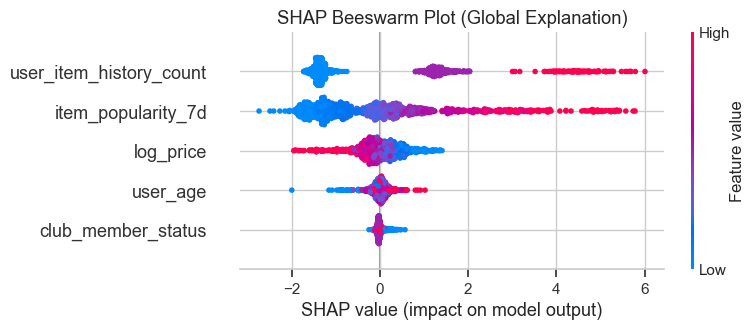

In [5]:
# 绘制全局蜂群图
plt.title("SHAP Beeswarm Plot (Global Explanation)")
shap.summary_plot(shap_values_pos, X_val[:1000], plot_type="dot")


### 3.2 局部解释：瀑布图 (Waterfall Plot)
随机选取**一条样本**，拆解该用户购买行为的决策过程。

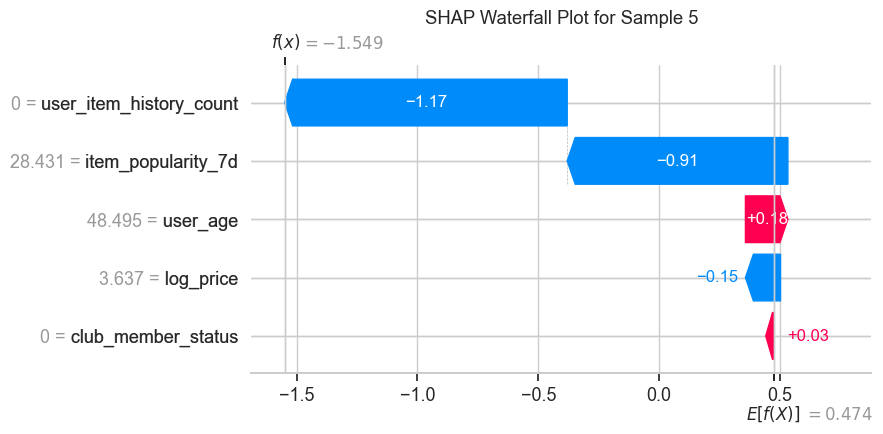

In [6]:
# 选取第 5 号样本进行局部解释
sample_idx = 5

# 对于新版 shap.plots.waterfall，需要传入 shap.Explanation 对象
explanation = shap.Explanation(
    values=shap_values_pos[sample_idx], 
    base_values=explainer.expected_value[1] if isinstance(explainer.expected_value, list) else explainer.expected_value, 
    data=X_val.iloc[sample_idx].values,
    feature_names=features
)

plt.figure(figsize=(8, 5))
plt.title(f"SHAP Waterfall Plot for Sample {sample_idx}")
shap.plots.waterfall(explanation)
plt.show()


### 3.3 模型学到了什么规律？（总结）

结合 SHAP 蜂群图与瀑布图的结果，模型主要学到了以下推荐规律：
1. **强转化信号驱动**：`user_item_history_count` (复购行为) 和 `item_popularity_7d` (近期热度) 的特征值越高，SHAP 值呈显著正向急剧增加，说明**历史复购和爆款效应是用户下单的决定性驱动力**。
2. **价格敏感性**：`log_price` 呈现明显的负相关（颜色红且在左侧），表明**高价格对用户的购买决策具有普遍的抑制作用**。